In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [4]:
df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')
if 'SalePrice' not in df2.columns:
  df2['SalePrice'] = 0
df = pd.concat([df1,df2], axis=0)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,0
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,0
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,0
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,0


In [5]:
df = df.drop(['PoolQC', 'Utilities', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage'],axis=1)
df

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,1936,Pave,Reg,Lvl,Inside,Gtl,MeadowV,...,0,0,0,0,0,6,2006,WD,Normal,0
1455,2916,160,RM,1894,Pave,Reg,Lvl,Inside,Gtl,MeadowV,...,0,0,0,0,0,4,2006,WD,Abnorml,0
1456,2917,20,RL,20000,Pave,Reg,Lvl,Inside,Gtl,Mitchel,...,0,0,0,0,0,9,2006,WD,Abnorml,0
1457,2918,85,RL,10441,Pave,Reg,Lvl,Inside,Gtl,Mitchel,...,0,0,0,0,700,7,2006,WD,Normal,0


In [6]:
df.isna().sum().sort_values(ascending=False).head(35)

GarageQual      159
GarageYrBlt     159
GarageFinish    159
GarageCond      159
GarageType      157
BsmtCond         82
BsmtExposure     82
BsmtQual         81
BsmtFinType2     80
BsmtFinType1     79
MasVnrArea       23
MSZoning          4
BsmtFullBath      2
BsmtHalfBath      2
Functional        2
GarageArea        1
SaleType          1
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1
Electrical        1
KitchenQual       1
GarageCars        1
Exterior2nd       1
Exterior1st       1
TotalBsmtSF       1
LotConfig         0
LandContour       0
LotShape          0
Street            0
LotArea           0
MSSubClass        0
Id                0
LandSlope         0
ExterQual         0
dtype: int64

In [7]:
df_null = df[df.isna().sum()[df.isna().sum()>0].index]
df_null

,MSZoning,Exterior1st,Exterior2nd,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,...,KitchenQual,Functional,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,SaleType
0,RL,VinylSd,VinylSd,196.0,Gd,TA,No,GLQ,706.0,Unf,...,Gd,Typ,Attchd,2003.0,RFn,2.0,548.0,TA,TA,WD
1,RL,MetalSd,MetalSd,0.0,Gd,TA,Gd,ALQ,978.0,Unf,...,TA,Typ,Attchd,1976.0,RFn,2.0,460.0,TA,TA,WD
2,RL,VinylSd,VinylSd,162.0,Gd,TA,Mn,GLQ,486.0,Unf,...,Gd,Typ,Attchd,2001.0,RFn,2.0,608.0,TA,TA,WD
3,RL,Wd Sdng,Wd Shng,0.0,TA,Gd,No,ALQ,216.0,Unf,...,Gd,Typ,Detchd,1998.0,Unf,3.0,642.0,TA,TA,WD
4,RL,VinylSd,VinylSd,350.0,Gd,TA,Av,GLQ,655.0,Unf,...,Gd,Typ,Attchd,2000.0,RFn,3.0,836.0,TA,TA,WD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,RM,CemntBd,CmentBd,0.0,TA,TA,No,Unf,0.0,Unf,...,TA,Typ,NaN,NaN,NaN,0.0,0.0,NaN,NaN,WD
1455,RM,CemntBd,CmentBd,0.0,TA,TA,No,Rec,252.0,Unf,...,TA,Typ,CarPort,1970.0,Unf,1.0,286.0,TA,TA,WD
1456,RL,VinylSd,VinylSd,0.0,TA,TA,No,ALQ,1224.0,Unf,...,TA,Typ,Detchd,1960.0,Unf,2.0,576.0,TA,TA,WD
1457,RL,HdBoard,Wd Shng,0.0,Gd,TA,Av,GLQ,337.0,Unf,...,TA,Typ,NaN,NaN,NaN,0.0,0.0,NaN,NaN,WD


In [8]:
df_null.select_dtypes(include= 'object')

,MSZoning,Exterior1st,Exterior2nd,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,SaleType
0,RL,VinylSd,VinylSd,Gd,TA,No,GLQ,Unf,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,WD
1,RL,MetalSd,MetalSd,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Typ,Attchd,RFn,TA,TA,WD
2,RL,VinylSd,VinylSd,Gd,TA,Mn,GLQ,Unf,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,WD
3,RL,Wd Sdng,Wd Shng,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Typ,Detchd,Unf,TA,TA,WD
4,RL,VinylSd,VinylSd,Gd,TA,Av,GLQ,Unf,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,WD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,RM,CemntBd,CmentBd,TA,TA,No,Unf,Unf,SBrkr,TA,Typ,NaN,NaN,NaN,NaN,WD
1455,RM,CemntBd,CmentBd,TA,TA,No,Rec,Unf,SBrkr,TA,Typ,CarPort,Unf,TA,TA,WD
1456,RL,VinylSd,VinylSd,TA,TA,No,ALQ,Unf,SBrkr,TA,Typ,Detchd,Unf,TA,TA,WD
1457,RL,HdBoard,Wd Shng,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Typ,NaN,NaN,NaN,NaN,WD


In [9]:
cols_obj = ['MSZoning', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType', 'Street']
for col in cols_obj:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df.isna().sum().sort_values(ascending=False).head(35)

GarageYrBlt     159
MasVnrArea       23
BsmtHalfBath      2
BsmtFullBath      2
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1
TotalBsmtSF       1
GarageCars        1
GarageArea        1
LandSlope         0
LandContour       0
LotShape          0
Street            0
LotArea           0
MSZoning          0
MSSubClass        0
Id                0
LotConfig         0
RoofMatl          0
YearRemodAdd      0
YearBuilt         0
Neighborhood      0
Condition2        0
Condition1        0
ExterCond         0
ExterQual         0
Exterior2nd       0
Exterior1st       0
BsmtExposure      0
BsmtCond          0
Foundation        0
BsmtQual          0
BsmtFinType2      0
BsmtFinType1      0
dtype: int64

In [11]:
cols_int = ['GarageYrBlt', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath', 'TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'GarageCars', 'GarageArea']
for cols in cols_int:
  df[cols] = df[cols].fillna(df[cols].median())

In [12]:
df.select_dtypes(include='object')

,MSZoning,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,...,SBrkr,TA,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,...,SBrkr,Gd,Typ,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,RM,Pave,Reg,Lvl,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
1455,RM,Pave,Reg,Lvl,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,...,SBrkr,TA,Typ,CarPort,Unf,TA,TA,Y,WD,Abnorml
1456,RL,Pave,Reg,Lvl,Inside,Gtl,Mitchel,Norm,Norm,1Fam,...,SBrkr,TA,Typ,Detchd,Unf,TA,TA,Y,WD,Abnorml
1457,RL,Pave,Reg,Lvl,Inside,Gtl,Mitchel,Norm,Norm,1Fam,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal


In [13]:
df_reset = df.reset_index(drop=True)
cols_obj_1 = df_reset.select_dtypes(include='object').columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df_reset[cols_obj_1])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cols_obj_1), index=df_reset.index)
df_numerical_and_other_cols = df_reset.drop(columns=cols_obj_1)
df_final = pd.concat([df_numerical_and_other_cols, encoded_df], axis=1)
df_final

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,8450,7,5,2003,2003,196.0,706.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,20,9600,6,8,1976,1976,0.0,978.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,60,11250,7,5,2001,2002,162.0,486.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,70,9550,7,5,1915,1970,0.0,216.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,60,14260,8,5,2000,2000,350.0,655.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,1936,4,7,1970,1970,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2915,2916,160,1894,4,5,1970,1970,0.0,252.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2916,2917,20,20000,5,7,1960,1996,0.0,1224.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2917,2918,85,10441,5,5,1992,1992,0.0,337.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [96]:
df_final= df_final[df_final["SalePrice"] < 450000]
df_final['Age_house'] = 2026- df_final['YearBuilt']
df_final = df_final.drop('YearBuilt', axis=1)

In [97]:
df_train = df_final[df_final['Id'] <= len(df1)]
df_test = df_final[df_final['Id'] > len(df1)]
X_test = df_test.drop('SalePrice', axis=1)

y_train = df_train["SalePrice"]
y_train = np.log1p(y_train)
X_train = df_train.drop("SalePrice", axis=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [98]:
X_train

array([[-1.72707477,  0.07081636, -0.19920004, ...,  0.46271567,
        -0.29945945, -1.06196197],
       [-1.7247047 , -0.8718806 , -0.08331727, ...,  0.46271567,
        -0.29945945, -0.16507871],
       [-1.72233463,  0.07081636,  0.08294932, ...,  0.46271567,
        -0.29945945, -0.99552617],
       ...,
       [ 1.72611428,  0.3064906 , -0.13954561, ...,  0.46271567,
        -0.29945945,  0.99754773],
       [ 1.72848435, -0.8718806 , -0.07152746, ...,  0.46271567,
        -0.29945945,  0.69858665],
       [ 1.73085442, -0.8718806 , -0.04935858, ...,  0.46271567,
        -0.29945945,  0.20031817]], shape=(1446, 264))

In [99]:
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
y_pred1 = np.expm1(y_pred1)


In [100]:
model2= RandomForestRegressor(n_estimators = 2000, max_depth= 8, max_leaf_nodes=2, criterion= 'squared_error', random_state = 0)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
y_pred2 = np.expm1(y_pred2)




In [101]:
model3 = xgb.XGBRegressor(n_estimators= 1000, max_depth= 10, learning_rate= 0.01)
model3.fit(X_train, y_train)#Best model
y_pred3 = model3.predict(X_test)
y_pred3 = np.expm1(y_pred3)

In [102]:
model4 = ElasticNet()
model4.fit(X_train, y_train)
y_pred4= model4.predict(X_test)
y_pred4 = np.expm1(y_pred4)


In [113]:
scores = cross_val_score(model1, X_train,np.expm1(y_train), scoring="neg_mean_squared_error", cv=5)
rmse = np.sqrt(-scores)

print("Average RMSE:", rmse.mean())


Average RMSE: inf


C:\Users\SANATH\AppData\Local\Temp\ipykernel_27212\355099282.py:2: RuntimeWarning: overflow encountered in expm1
  rmse = np.expm1(np.sqrt(-scores))


In [108]:
scores = cross_val_score(model2, X_train, np.expm1(y_train), scoring="neg_mean_squared_error", cv=5)
rmse = np.sqrt(-scores)
print("Average RMSE:", rmse.mean())

Average RMSE: 48737.37257784944


In [107]:
scores = cross_val_score(model3, X_train, np.expm1(y_train), scoring="neg_mean_squared_error", cv=5)
rmse = np.sqrt(-scores)
print("Average RMSE:", rmse.mean())

Average RMSE: 26648.14232642032


In [81]:
scores = cross_val_score(model4, X_train, y_train, scoring="neg_mean_squared_error", cv=5)
rmse = np.sqrt(-scores)
print("Average RMSE:", rmse.mean())

Average RMSE: 0.38286007134223377


In [92]:
feature_importance = model3.feature_importances_
imp_df = pd.DataFrame({'Feature': df_train.drop('SalePrice', axis=1).columns, 'Importance': feature_importance}).sort_values(by= 'Importance', ascending= False)
imp_df.head(20)

,Feature,Importance
3,OverallQual,0.358105
21,KitchenAbvGr,0.095659
25,GarageCars,0.079893
209,CentralAir_N,0.074247
232,GarageType_Detchd,0.035355
235,GarageFinish_Unf,0.028512
15,GrLivArea,0.023854
177,BsmtQual_TA,0.012425
11,TotalBsmtSF,0.012352
174,BsmtQual_Ex,0.011853


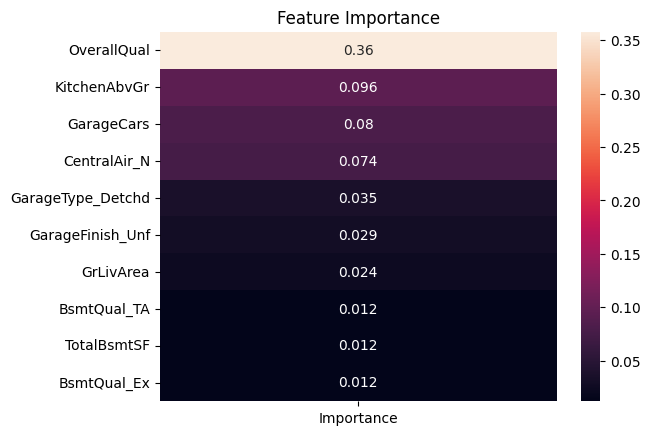

In [83]:
sns.heatmap(imp_df[['Importance']].head(10),  annot=True, yticklabels=imp_df.head(10)['Feature'])
plt.title('Feature Importance')
plt.show()

In [84]:
num_defaults = df1.select_dtypes(include=['number']).median()
cat_defaults = df1.select_dtypes(include=['object']).mode().iloc[0]
default_values = pd.concat([num_defaults, cat_defaults]).to_dict()


In [85]:
pickle.dump(model3, open('house_model.pkl', 'wb'))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))
with open("default_feature_values.pkl", "wb") as f:
    pickle.dump(default_values, f)

In [86]:
categorical_cols = cols_obj_1  

import pickle
pickle.dump(categorical_cols, open("categorical_cols.pkl", "wb"))

In [90]:
pickle.dump(df_train.drop("SalePrice", axis=1).columns.tolist(), open("final_feature_order.pkl", "wb"))

In [93]:
df['ExterCond'].value_counts()

ExterCond
TA    2538
Gd     299
Fa      67
Ex      12
Po       3
Name: count, dtype: int64